In [8]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
# 加载 .mat 文件
GNSS_data = loadmat('workbench/workbench/Earthquake_predictor/reference_project/RSIT/GNSS_South_central_Alaska_20180101_20181231.mat')['GNSS_South_central_Alaska_20180101_20181231']
print(GNSS_data.shape)
earthquake_data = loadmat('/home/linhang/workbench/workbench/Earthquake_predictor/reference_project/RSIT/South_central_Alaska_earthquake_event.mat')['South_central_Alaska_earthquake_event']
print(earthquake_data.shape)

(365, 16)
(4, 365)


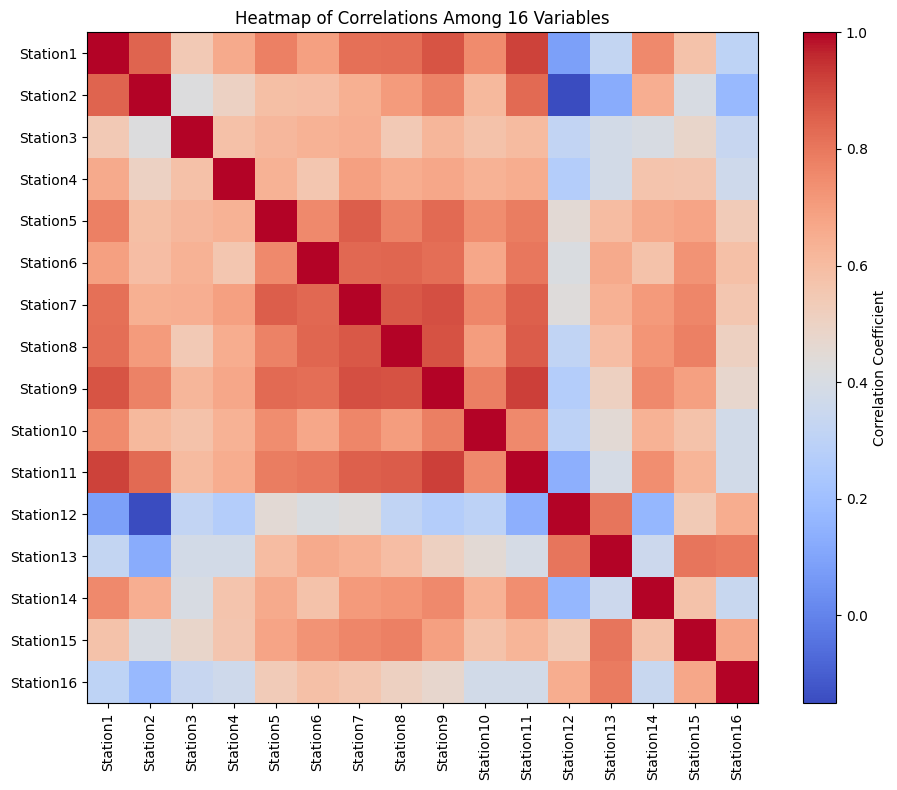

In [4]:
# Calculate the correlation matrix
correlation_matrix = np.corrcoef(GNSS_data.T)

# Plot the heatmap
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')
plt.title('Heatmap of Correlations Among 16 Variables')
plt.xticks(range(16), labels=[f'Station{i+1}' for i in range(16)], rotation=90)
plt.yticks(range(16), labels=[f'Station{i+1}' for i in range(16)])
plt.tight_layout()
plt.show()

/tmp/ipykernel_71079/3051535010.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


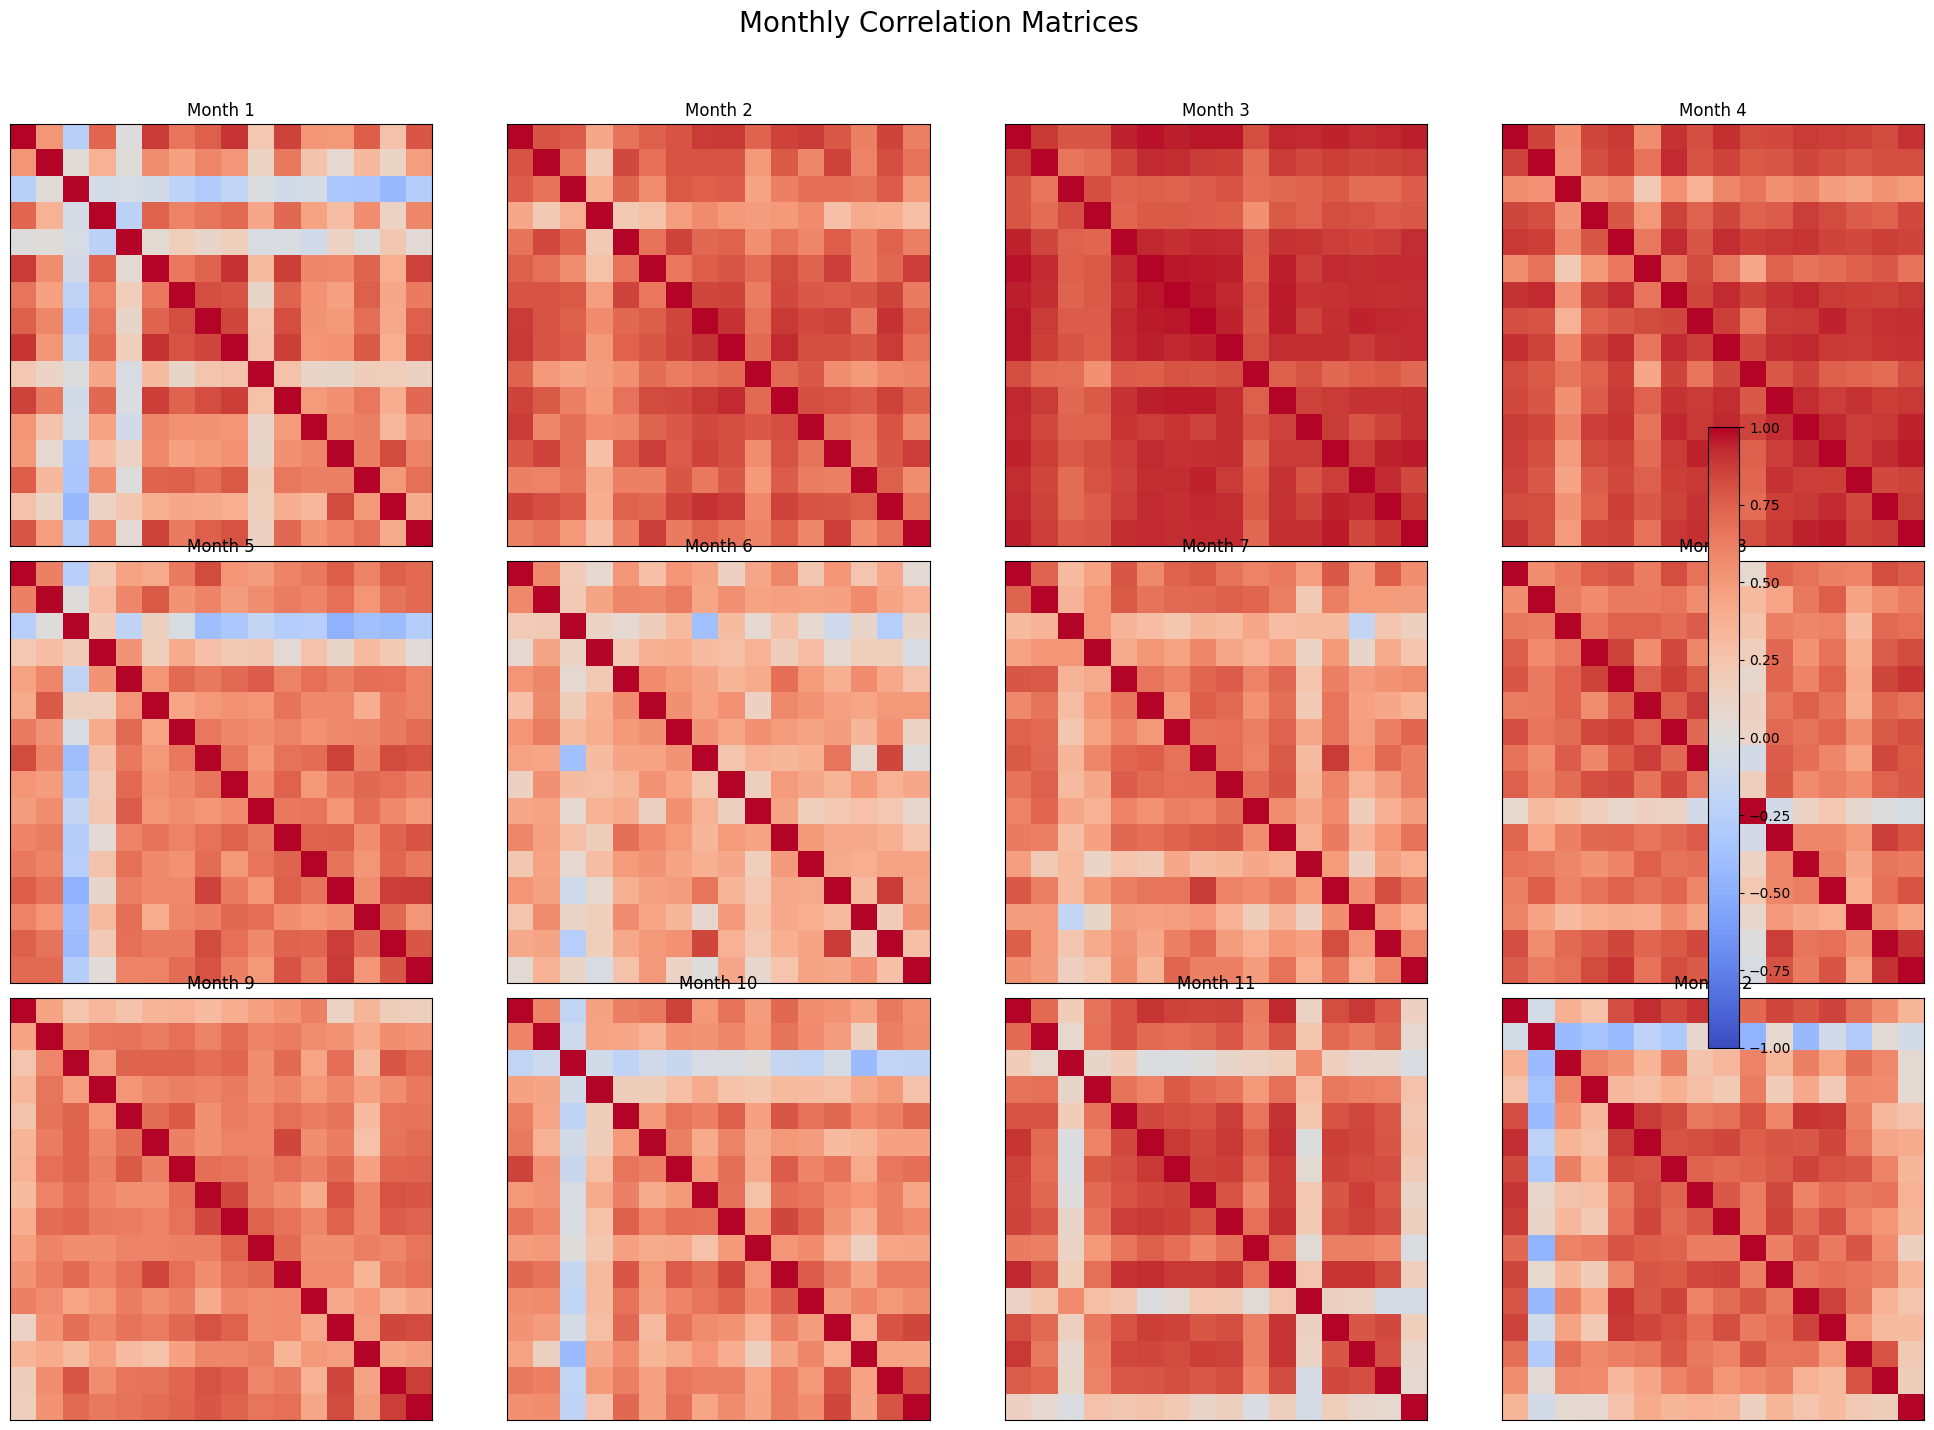

In [5]:
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

# Split the data into months
monthly_correlation_matrices = []
start_idx = 0
for days in days_in_month:
    end_idx = start_idx + days
    monthly_data = GNSS_data.T[:, start_idx:end_idx]
    monthly_corr = np.corrcoef(monthly_data)
    monthly_correlation_matrices.append(monthly_corr)
    start_idx = end_idx

# Plotting correlation changes over months as a heatmap sequence
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(monthly_correlation_matrices):
        cax = ax.imshow(monthly_correlation_matrices[i], cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
        ax.set_title(f'Month {i + 1}')
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.axis('off')

fig.colorbar(cax, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
plt.suptitle('Monthly Correlation Matrices', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
earthquake_magnitudes = earthquake_data[0]
days_with_large_quakes = np.where(earthquake_magnitudes > 5)[0] + 1  # Convert to 1-based index

# Map these days to months
month_mapping = []
start_day = 1
for month, days in enumerate(days_in_month, start=1):
    for day in range(start_day, start_day + days):
        month_mapping.append(month)
    start_day += days

# Get the corresponding months for the identified days
large_quake_months = [month_mapping[day - 1] for day in days_with_large_quakes]

# Count the number of large earthquakes in each month
large_quake_counts = {month: large_quake_months.count(month) for month in range(1, 13)}

import pandas as pd
quake_data = pd.DataFrame(list(large_quake_counts.items()), columns=["Month", "Count"])

<Axes: xlabel='Month'>

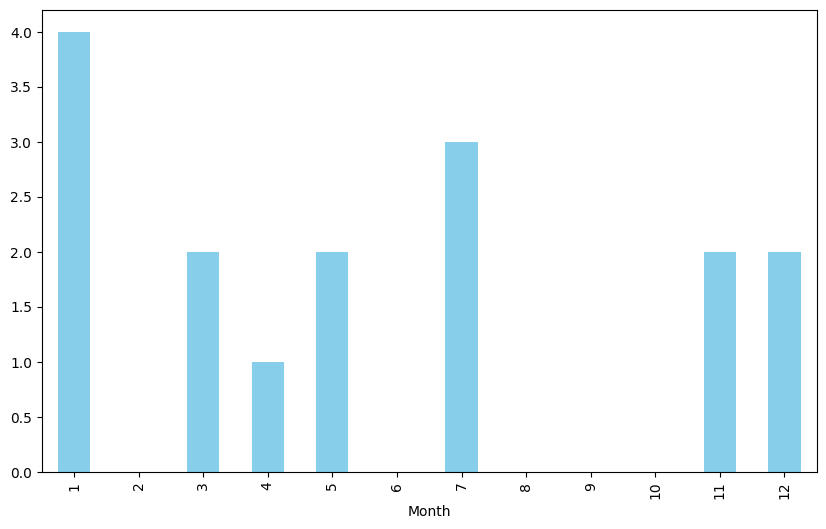

In [10]:
quake_data.plot(kind='bar', x='Month', y='Count', legend=False, color='skyblue', figsize=(10, 6))

In [47]:
a = [1,2,3,4,5]
a[:3]

[1, 2, 3]

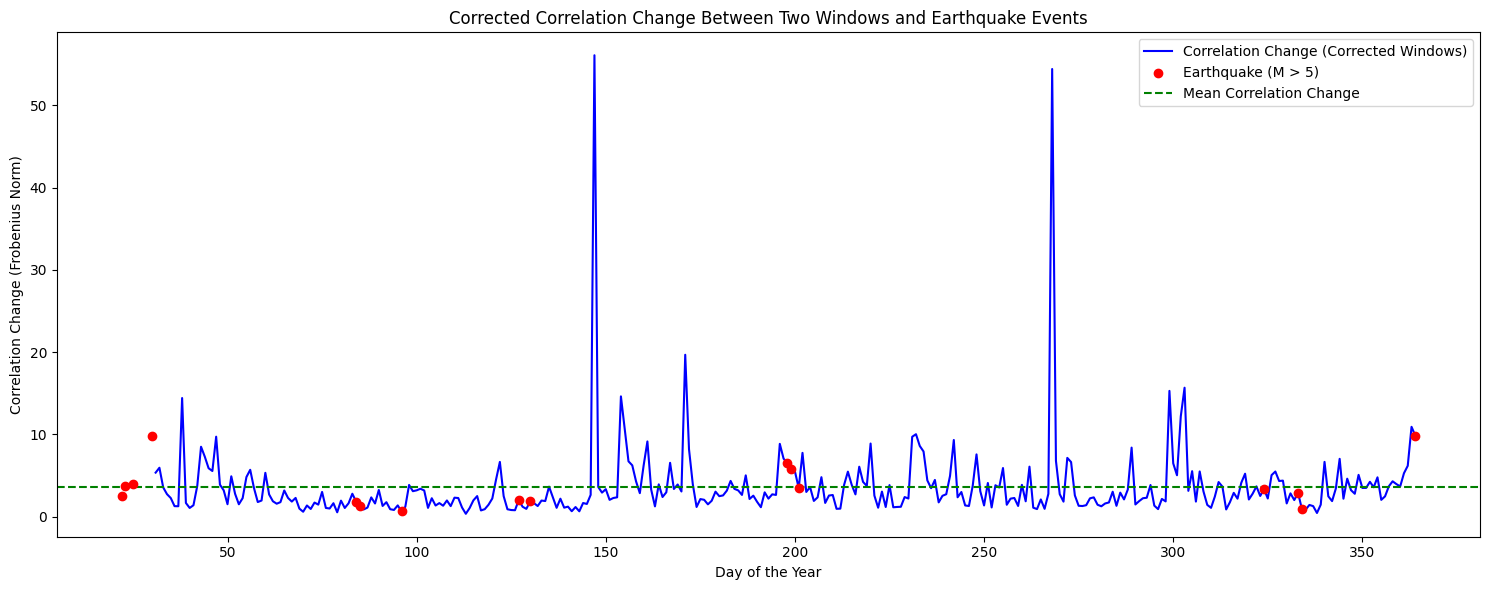

In [53]:
correlation_indicators = []
data = GNSS_data.T
earthquake_days = np.where(earthquake_magnitudes > 5)[0]  # Days with large earthquakes

long_window_size = 31
short_window_size = 30

correlation_changes_corrected = []

# Loop through each day, starting from the 18th day (index 17)
for t in range(long_window_size, 365):
    # Define two corrected overlapping windows
    window_A_data = data[:, t - long_window_size:t]  # t-18 to t-4
    window_B_data = data[:, t - short_window_size:t]  # t-14 to t
    
    # Calculate correlation matrices for the two windows
    corr_A = np.abs(np.corrcoef(window_A_data))
    corr_B = np.abs(np.corrcoef(window_B_data))
    
    # Compute the difference between the two correlation matrices (Frobenius norm)
    correlation_diff = np.sum(np.abs(corr_A - corr_B))
    correlation_changes_corrected.append(correlation_diff)

# Plot the corrected correlation changes and earthquake events
plt.figure(figsize=(15, 6))
plt.plot(range(long_window_size, 365), correlation_changes_corrected, label='Correlation Change (Corrected Windows)', color='blue')
plt.scatter(earthquake_days, 
            [correlation_changes_corrected[day - long_window_size] for day in earthquake_days],
            color='red', label='Earthquake (M > 5)', zorder=5)
plt.axhline(np.mean(correlation_changes_corrected), color='green', linestyle='--', label='Mean Correlation Change')
plt.xlabel('Day of the Year')
plt.ylabel('Correlation Change (Frobenius Norm)')
plt.title('Corrected Correlation Change Between Two Windows and Earthquake Events')
plt.legend()
plt.tight_layout()
plt.show()

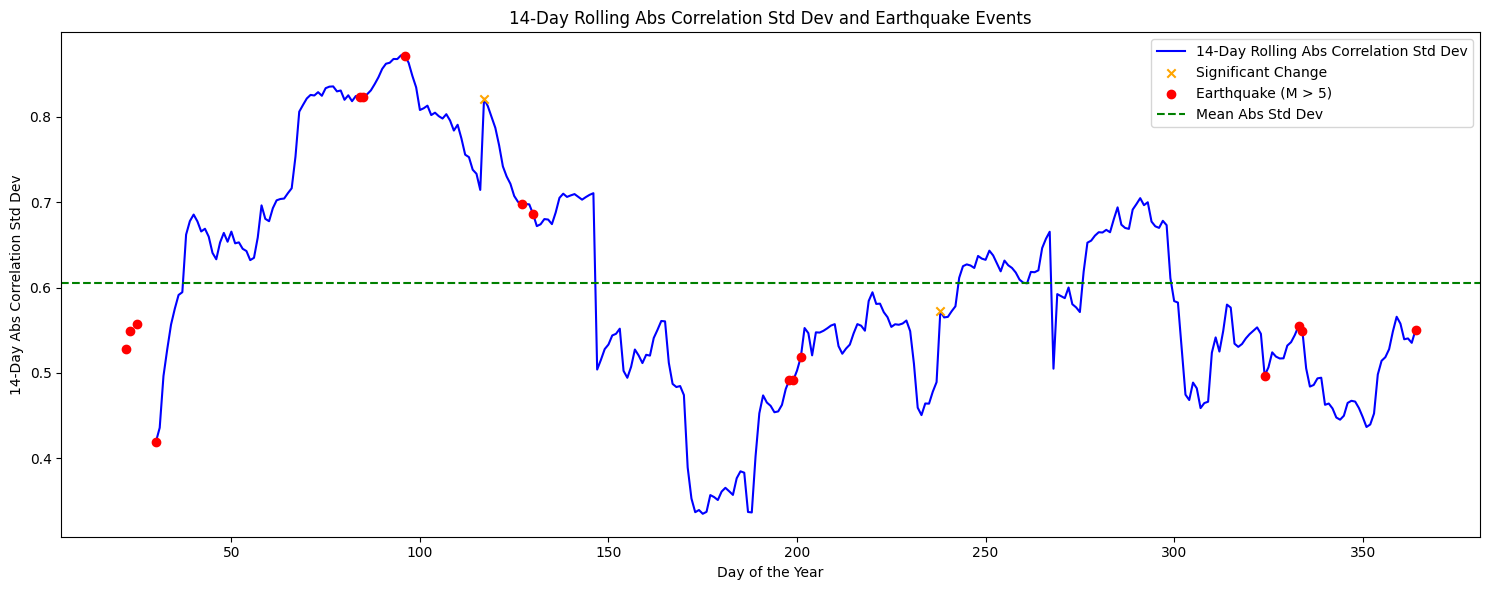

In [79]:
earthquake_days = np.where(earthquake_magnitudes > 5)[0]

rolling_abs_correlation_std = []

window_size = 30

# Loop through each day, starting from the 15th day (index 14)
for t in range(window_size, 365):
    # Extract data from the past 14 days
    past_14_days_data = data[:, t - window_size:t]
    
    # Calculate correlation matrix for the 14-day window
    window_corr = np.corrcoef(past_14_days_data)
    
    # Take absolute value of the correlation matrix
    abs_window_corr = np.abs(window_corr)
    
    # Calculate the standard deviation of the absolute correlation matrix elements
    abs_corr_std = np.mean(abs_window_corr[np.triu_indices_from(abs_window_corr, k=1)])  # Exclude diagonal
    rolling_abs_correlation_std.append(abs_corr_std)

# Plot the rolling absolute standard deviation of correlation changes and earthquake events
plt.figure(figsize=(15, 6))
plt.plot(range(window_size, 365), rolling_abs_correlation_std, label='14-Day Rolling Abs Correlation Std Dev', color='blue')
std_diff = np.abs(np.diff(rolling_abs_correlation_std))

std_diff = np.insert(std_diff, 0, 0)
std_diff_idx = np.where(std_diff > 0.15)[0]

plt.scatter(std_diff_idx, [rolling_abs_correlation_std[int(day - window_size)] for day in std_diff_idx], color='orange', label='Significant Change', zorder=5,marker='x')
plt.scatter(earthquake_days, 
            [rolling_abs_correlation_std[int(day - window_size)] for day in earthquake_days],
            color='red', label='Earthquake (M > 5)', zorder=5)

plt.axhline(np.mean(rolling_abs_correlation_std), color='green', linestyle='--', label='Mean Abs Std Dev')
plt.xlabel('Day of the Year')
plt.ylabel('14-Day Abs Correlation Std Dev')
plt.title('14-Day Rolling Abs Correlation Std Dev and Earthquake Events')
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
std_diff_idx

array([ 31,  78,  87, 117, 172, 239, 246, 247])

In [75]:
earthquake_days

array([ 22,  23,  25,  30,  84,  85,  96, 127, 130, 198, 199, 201, 324,
       333, 334, 364])

In [64]:
rolling_abs_correlation_std[std_diff_idx]

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
def myLeakyRelu(x, leak, flag):
    """
    Apply LeakyReLU activation function.

    Args:
        x (ndarray): Input data.
        leak (float): Slope for negative values.
        flag (int): 1 for standard LeakyReLU, 2 for inverse LeakyReLU.

    Returns:
        ndarray: Activated output.
    """
    myleak = leak if flag == 1 else 1 / leak
    output = np.where(x >= 0, x, myleak * x)
    return output

In [ ]:

def NN_transform(traindata, weights):
    """
    Transform data using a neural network structure.

    Args:
        traindata (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata.shape
    output = np.zeros((weights[-1].shape[1], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata[:, i]  # Input for the current timestep
        for weight in weights:
            curr_layer_nodes_value = np.dot(pre_layer_nodes_value, weight)
            # Apply activation function (tanh or LeakyReLU)
            curr_layer_nodes_value = np.tanh(curr_layer_nodes_value / 3.0)
            curr_layer_nodes_value = myLeakyRelu(curr_layer_nodes_value, leak=0.01, flag=1)
            pre_layer_nodes_value = curr_layer_nodes_value
        output[:, i] = curr_layer_nodes_value  # Store result for this timestep
    
    return output

In [ ]:
def NN_transform_reverse(traindata_NN, weights):
    """
    Reverse transform using a neural network structure.

    Args:
        traindata_NN (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Reverse transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata_NN.shape
    output = np.zeros((weights[0].shape[0], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata_NN[:, i]
        for weight in reversed(weights):
            pre_layer_nodes_value = myLeakyRelu(np.dot(pre_layer_nodes_value, weight.T), leak=0.01, flag=1)
        output[:, i] = pre_layer_nodes_value
    
    return output

In [ ]:
def weights_align1(weight_a, weight_b, weight_c, input_dimension):
    """
    Generate weights for the neural network.

    Args:
        weight_a, weight_b, weight_c (int): Number of nodes in each layer.
        input_dimension (int): Input dimension.

    Returns:
        tuple: (all_weights, reverse_all_weights), both are lists of weight matrices.
    """
    post_nodes_num = [weight_a, weight_b, weight_c]
    layer_nodes_num = [input_dimension] + post_nodes_num
    
    all_weights = []
    reverse_all_weights = []
    
    for l in range(1, len(layer_nodes_num)):
        weight_matrix = np.random.randn(layer_nodes_num[l - 1], layer_nodes_num[l])
        all_weights.append(weight_matrix)
        reverse_all_weights.append(np.linalg.pinv(weight_matrix))
    
    return all_weights, reverse_all_weights

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定义参数
samples = 11
embeddings_num = 5
weight_a = 190
weight_b = 10
weight_c = 5
stationnum = 16
sample_use = 365

altitude_matrix = GNSS_data.T  # 转置矩阵以匹配原 MATLAB 的维度
#(16,365)
# 初始化变量
timepoint = sample_use - samples + 1
normal_sd_y = np.zeros(timepoint)
normal_sd_original = np.zeros((stationnum, timepoint))

# 随机种子
np.random.seed(42)
ii = 0
iterations = 1  # 设置迭代次数


In [ ]:
normal_zone = np.arange(0, 0 + samples)
UU = altitude_matrix[:, normal_zone]
print(UU.shape)

In [ ]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# 设置随机数种子
import random

# 初始化参数
samples = 11
embeddings_num = 5
weight_a = 190
weight_b = 10
weight_c = 5
stationnum = 16
sample_use = 365

altitude_matrix_databeihaidao1 = GNSS_data.T

# 计算时间点
timepoint = sample_use - samples + 1

# 初始化变量
normal_sd_y = np.zeros((timepoint, 1))
normal_sd_original = np.zeros((stationnum, timepoint))
critical_sd_y = 0
ii = 0
good_ii = 0
reps = 0
nreps = 0


# 主循环，执行10000次迭代
while ii < 10000:
    ii += 1
    input_dimensions = stationnum

    # 获取权重矩阵
    all_weights, reverse_all_weights = weights_align1(weight_a, weight_b, weight_c, altitude_matrix_databeihaidao1.shape[0])

    # 样本的关键区域
    critical_zone = np.arange(sample_use - samples, sample_use)

    normal_start = 0

    # 内部循环，遍历所有可能的正常区域
    while normal_start + samples - 1 < sample_use:
        normal_start += 1
        normal_zone = np.arange(normal_start - 1, normal_start + samples - 1)
        myzone = [normal_zone]
        # 计算正常区域的标准差
        normal_sd_original[:, normal_start - 1] = np.std(altitude_matrix_databeihaidao1[:, myzone[0]], axis=1, ddof=0)
    
        for mys in range(1):
            UU = altitude_matrix_databeihaidao1[:, myzone[mys]]

            input_dimensions, time_points = UU.shape # 16, 11

            flat_y = np.zeros((time_points + embeddings_num - 1, 1))
            xx = UU
            noisestrength = 0  # 可以添加噪声
            xx_noise = xx + noisestrength * np.random.rand(*xx.shape)
            D = xx_noise.shape[0]  # 系统中的变量数量 16
            trainlength = time_points

            traindata = xx_noise[:, :trainlength]

            traindata_x_NN = NN_transform(traindata, all_weights)
            test_NN = traindata_x_NN #(5, 11)
            
            F_dimensions = traindata_x_NN.shape[0]

            # 求解权重矩阵A
            AA_rows = (trainlength - 1) * (embeddings_num - 1) + 1
            AA_cols = embeddings_num * F_dimensions

            AA = np.zeros((AA_rows, AA_cols)) #41, 25
            b = np.zeros((AA_rows, 1))

            for k in range(embeddings_num - 1):
                for t in range(1, trainlength):
                    row_idx = k * (trainlength - 1) + t - 1
                    AA[row_idx, k * F_dimensions: (k + 1) * F_dimensions] = traindata_x_NN[:, t]
                    AA[row_idx, (k + 1) * F_dimensions: (k + 2) * F_dimensions] = -traindata_x_NN[:, t - 1]

            AA[(trainlength - 1) * (embeddings_num - 1), 0:F_dimensions] = traindata_x_NN[:, 1]
            b[(trainlength - 1) * (embeddings_num - 1), 0] = traindata_x_NN[0, 0]

            # 求解线性方程 AA * flat_A = b

            flat_A, residuals, rank, s_vals = np.linalg.lstsq(AA, b, rcond=None)

            flat_A = flat_A.flatten()

            weight_A = np.zeros((embeddings_num, F_dimensions))
            for i in range(embeddings_num):
                weight_A[i, :] = flat_A[i * F_dimensions: (i + 1) * F_dimensions]

            # 计算Y
            Y = np.dot(weight_A, traindata_x_NN)  # Y的大小为 (embeddings_num, trainlength)

            # 计算权重矩阵B
            B = np.dot(traindata_x_NN, np.linalg.pinv(Y))
            X_real = xx_noise[:, :trainlength]
            II = np.dot(weight_A, B)

            for t in range(trainlength):
                min_val = min(t + 1, embeddings_num)
                for j in range(min_val):
                    m = t - j
                    l = j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= min_val

            for t in range(trainlength, trainlength + embeddings_num - 1):
                max_j = embeddings_num - (t - trainlength)
                for j in range(max_j):
                    m = trainlength - j - 1
                    l = t - trainlength + j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= max_j

            # 计算标准差
            if 'sd1' not in locals():
                sd1 = np.zeros((1, flat_y.shape[0]))
                test_flat_y = np.zeros((1, flat_y.shape[0]))
            sd1[mys, :] = np.std(flat_y, axis=0, ddof=0)
            test_flat_y[mys, :] = flat_y.flatten()

        normal_sd_y[normal_start - 1, 0] += np.std(test_flat_y[0, :], ddof=0)
        reps += 1
    # 打印进度
    if ii % 100 == 0:
        print(ii)

# 计算平均标准差
normal_sd_y = normal_sd_y / ii

# 保存结果
combined_sd_y_South_central_Alaska = normal_sd_y.flatten()
plt.figure()
plt.plot(combined_sd_y_South_central_Alaska)
plt.show()

In [ ]:
normal_sd_y = normal_sd_y / ii

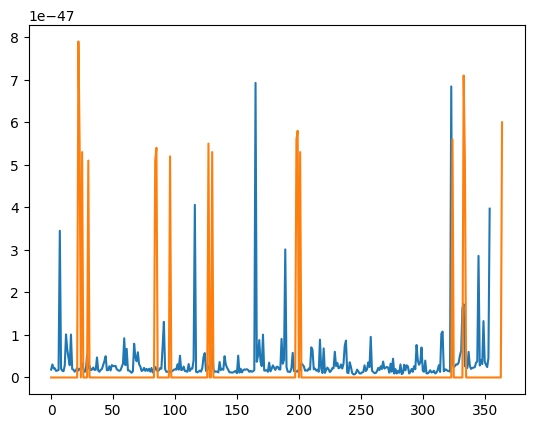

In [25]:


# 保存结果
combined_sd_y_South_central_Alaska = normal_sd_y.flatten()
plt.figure()
plt.plot(combined_sd_y_South_central_Alaska)
plt.plot([i/1e47 if i > 5 else 0 for i in earthquake_data[0]])

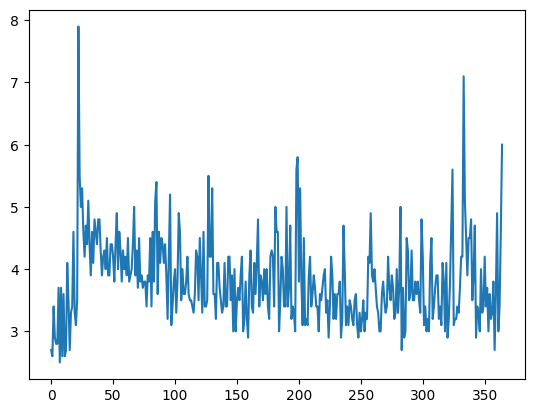

In [12]:
plt.plot(earthquake_data[0,:])